# Description: Evaluate NORDIC ability at removing Thermal Noise (Evaluation Dataset)

Prior to using this notebook, you need to run the ```bash/S03_ThermalNoiseEstimation...``` script to estimate thermal noise in all scans and TEs from both datasets.

For each scan, this script will write two files:

* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt```: holds thermal noise estimates before applying NORDIC.
* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt```: holds thermal noise estimates after applying NORDIC.

Expectations:

* Thermal noise should be TE independent, yet becuase the suboptimal way in which we are measuring thermal noise, a slight difference migth occur.
* Thermal noise should be significantly smaller after NORDIC for all echoes.

In [3]:
import pandas as pd
import os.path as osp
import hvplot.pandas
import seaborn as sns
import numpy as np
import pandas as pd
import panel as pn
from tqdm import tqdm
from utils.basics import PRCS_DATA_DIR, PRJ_DIR
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
import xarray as xr
import hvplot.xarray
import holoviews as hv


### Load list of scans from the Evaluation dataset entering the final set of analyses

In [4]:
dataset_info_df = pd.read_csv(osp.join(PRJ_DIR,'resources','good_scans.txt'))
dataset_info_df = dataset_info_df.set_index(['Subject','Session'])
print('++ Number of scans: %s scans' % dataset_info_df.shape[0])

++ Number of scans: 439 scans


### Load the Thermmal noise estiamtes for these scans

In [5]:
df_list = []
for sbj,ses in tqdm(dataset_info_df.index, desc='Scan'):
    for e in range(1,4):
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'NORDIC':'off','Echo':e,'Thermal Noise':np.mean(aux[10::])})
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'NORDIC':'on','Echo':e,'Thermal Noise':np.mean(aux[10::])})
df = pd.DataFrame(df_list)

Scan: 100%|██████████| 439/439 [00:08<00:00, 51.11it/s]


### Separate the data by session ID

In [6]:
df_ses1 = df.set_index('Session').loc['ses-1'].copy().reset_index(drop=True)
df_ses2  = df.set_index('Session').loc['ses-2'].copy().reset_index(drop=True)

### Print the overall improvement in Thermal Noise for the whole dataset

In [7]:
aux = (100 * (df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'off',:] - df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'on',:]) / df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'off',:]).describe()
print('Thermal Noise reduction after NORDIC (%%): %0.2f +/- %0.2f' % (aux.loc['mean'].values[0],aux.loc['std'].values[0]))

Thermal Noise reduction after NORDIC (%): 28.79 +/- 1.84


### Generate Suppl. Figure 2.b panel

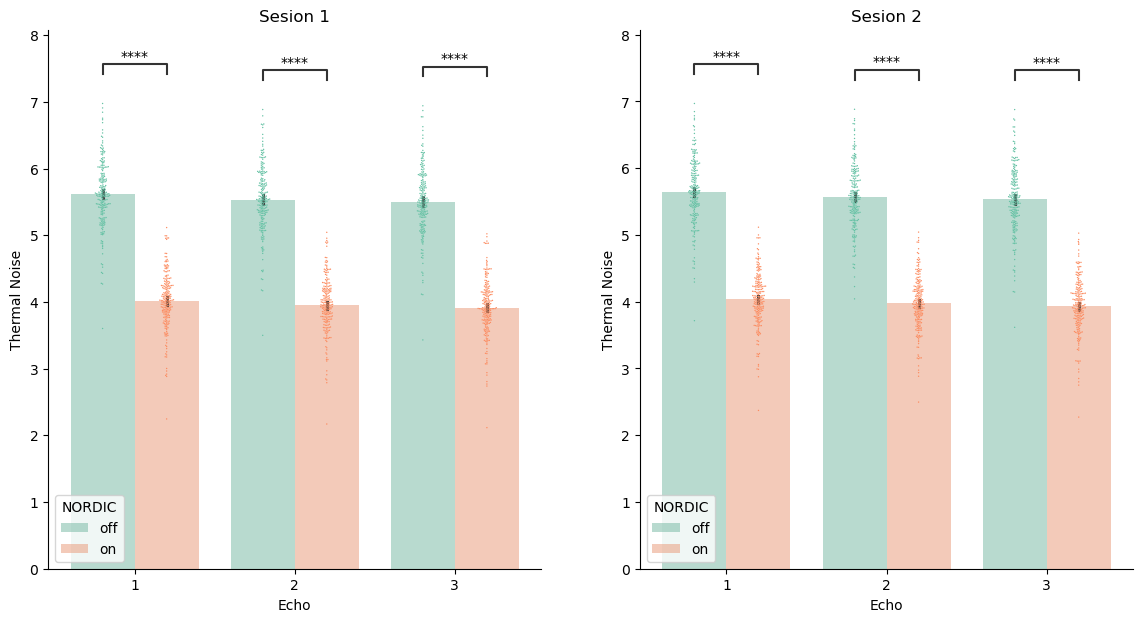

In [8]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ses1,hue='NORDIC',x='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Sesion 1')
sns.swarmplot(data=df_ses1,hue='NORDIC',x='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False, size=1)
pairs=[((1,'off'),(1,'on')),((2,'off'),(2,'on')),((3,'off'),(3,'on'))]
annotation = Annotator(axs[0], pairs, data=df_ses1, hue='NORDIC', y='Thermal Noise',x='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_ses2,hue='NORDIC',x='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Sesion 2')
sns.swarmplot(data=df_ses2,hue='NORDIC',x='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False, size=1)
pairs=[((1,'off'),(1,'on')),((2,'off'),(2,'on')),((3,'off'),(3,'on'))]
sns.despine()
annotation = Annotator(axs[1], pairs, data=df_ses2, hue='NORDIC', y='Thermal Noise',x='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();

### END

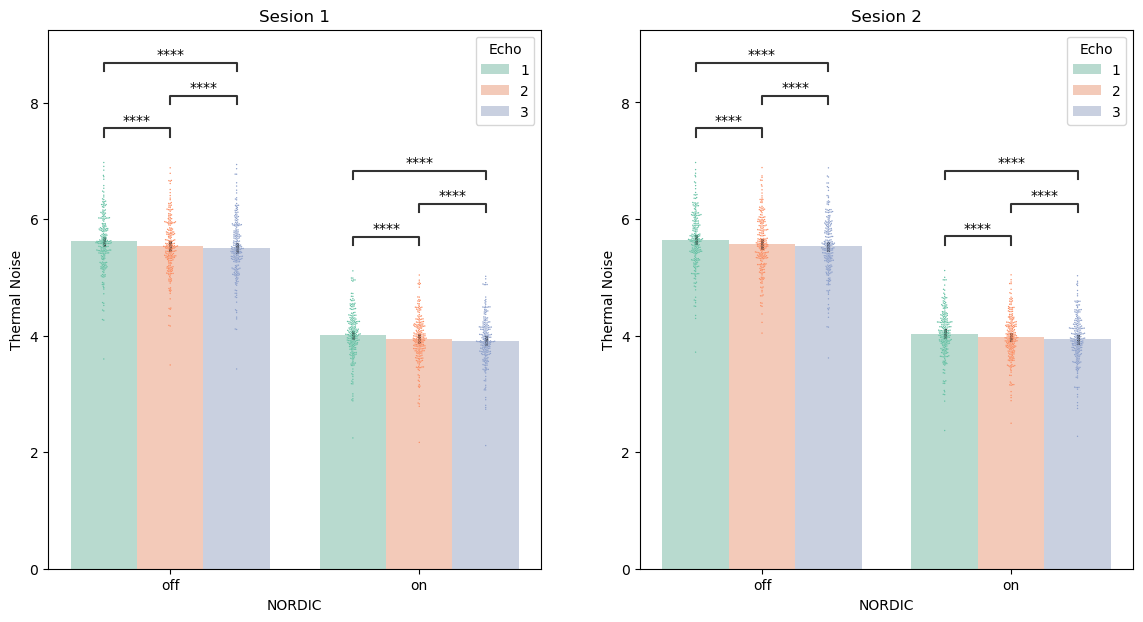

In [18]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ses1,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Sesion 1')
sns.swarmplot(data=df_ses1,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False, size=1)
pairs=[(('off',1),('off',2)),(('off',2),('off',3)),(('off',1),('off',3)),(('on',1),('on',2)),(('on',2),('on',3)),(('on',1),('on',3))]
annotation = Annotator(axs[0], pairs, data=df_ses1, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_ses2,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Sesion 2')
sns.swarmplot(data=df_ses2,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False, size=1)
pairs=[(('off',1),('off',2)),(('off',2),('off',3)),(('off',1),('off',3)),(('on',1),('on',2)),(('on',2),('on',3)),(('on',1),('on',3))]
annotation = Annotator(axs[1], pairs, data=df_ses2, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();

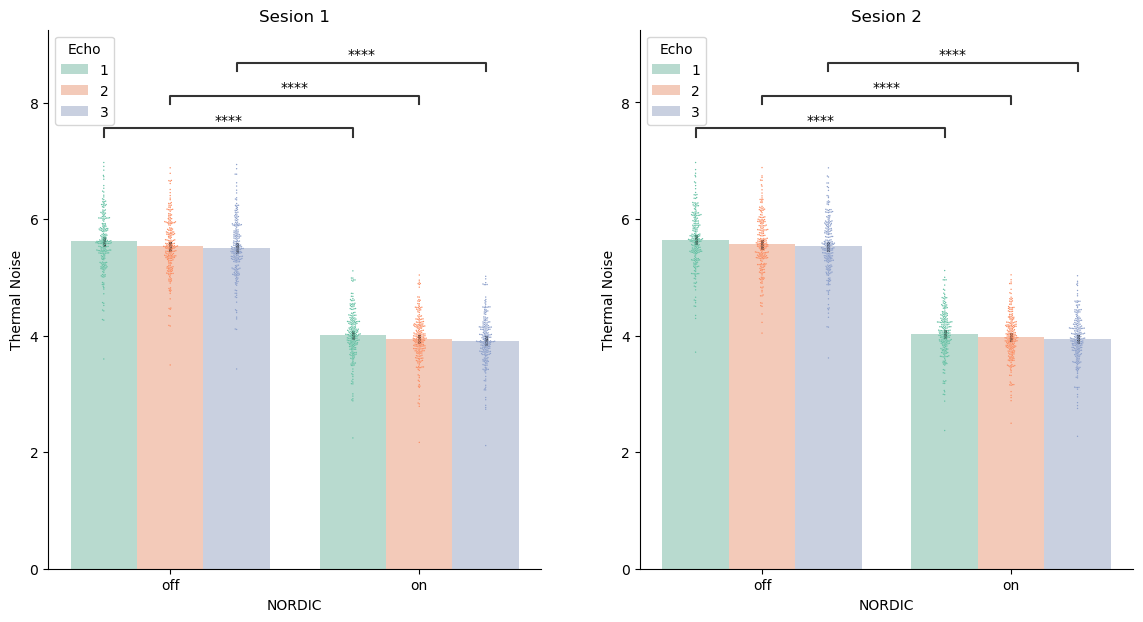

In [19]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ses1,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Sesion 1')
sns.swarmplot(data=df_ses1,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False, size=1)
pairs=[(('off',1),('on',1)),(('off',2),('on',2)),(('off',3),('on',3))]
annotation = Annotator(axs[0], pairs, data=df_ses1, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_ses2,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Sesion 2')
sns.swarmplot(data=df_ses2,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False, size=1)
pairs=[(('off',1),('on',1)),(('off',2),('on',2)),(('off',3),('on',3))]
sns.despine()
annotation = Annotator(axs[1], pairs, data=df_ses2, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();

In [21]:
(100 * (df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'off',:] - df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'on',:]) / df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'off',:]).describe()

,Thermal Noise
count,1317.000000
mean,28.790848
std,1.836428
min,24.094879
25%,27.617971
50%,28.846452
75%,29.747825
max,38.337489


In [22]:
df = df.infer_objects()
(100*(df.set_index('NORDIC').loc['off','Thermal Noise'].reset_index(drop=True) - df.set_index('NORDIC').loc['on','Thermal Noise'].reset_index(drop=True)) / df.set_index('NORDIC').loc['off','Thermal Noise'].reset_index(drop=True)).mean()

np.float64(28.790848203709015)

In [23]:
df2 = (100*(df.set_index('NORDIC').loc['off','Thermal Noise'].reset_index(drop=True) - df.set_index('NORDIC').loc['on','Thermal Noise'].reset_index(drop=True)) / df.set_index('NORDIC').loc['off','Thermal Noise'].reset_index(drop=True))

In [24]:
df2.hvplot.hist()

:Histogram   [Thermal Noise]   (Count)

In [25]:
pivot_df = df.pivot_table(
    index=["Subject", "Session", "Echo"],
    columns="NORDIC",
    values="Thermal Noise"
)

In [26]:
# Compute percent change: (off - on)/off * 100
pivot_df["Percent Change"] = (
    (pivot_df["off"] - pivot_df["on"]) / pivot_df["off"] * 100
)

In [29]:
avg_df = (
    pivot_df["Percent Change"]
    .groupby(["Subject", "Session"])
    .mean()
    .reset_index()
)

#avg_df.set_index(['Session']).loc['ses-1'].sort_values(by='Percent Change')
avg_df.set_index(['Session']).sort_values(by='Percent Change')

,Subject,Percent Change
Session,,
ses-1,sub-95,24.205965
ses-2,sub-95,24.630434
ses-2,sub-96,24.685683
ses-2,sub-87,24.737607
ses-1,sub-87,24.889113
...,...,...
ses-2,sub-16,33.831264
ses-2,sub-23,33.960453
ses-1,sub-16,34.431009


In [28]:
pivot_df.sort_values(by='Percent Change', ascending=False)[0:20]

NORDIC                     off        on  Percent Change
Subject Session Echo                                    
sub-20  ses-1   3     3.430430  2.115289       38.337489
        ses-2   2     4.042584  2.496289       38.250150
        ses-1   2     3.499105  2.169786       37.990260
                1     3.601950  2.245878       37.648289
        ses-2   3     3.616201  2.271543       37.184280
                1     3.715742  2.371328       36.181576
sub-16  ses-1   3     4.290049  2.806021       34.592315
                2     4.336565  2.845212       34.390201
                1     4.442339  2.918150       34.310512
sub-23  ses-2   1     4.837506  3.181952       34.223300
sub-31  ses-1   1     4.558635  3.002701       34.131578
sub-16  ses-2   3     4.313805  2.849652       33.941104
sub-50  ses-2   3     5.385006  3.558239       33.923210
sub-16  ses-2   2     4.501524  2.974824       33.915189
sub-23  ses-2   3     4.707535  3.111289       33.908317
                2     4.749716  3.146699       33.749741
sub-31  ses-1   3     4.430944  2.939882       33.651103
        ses-2   1     4.609751  3.058553       33.650359
sub-36  ses-2   3     4.145100  2.750351       33.648139
sub-16  ses-2   1     4.501325  2.987192       33.637499

Same as above, but showing statistical test across NORDIC scenarios

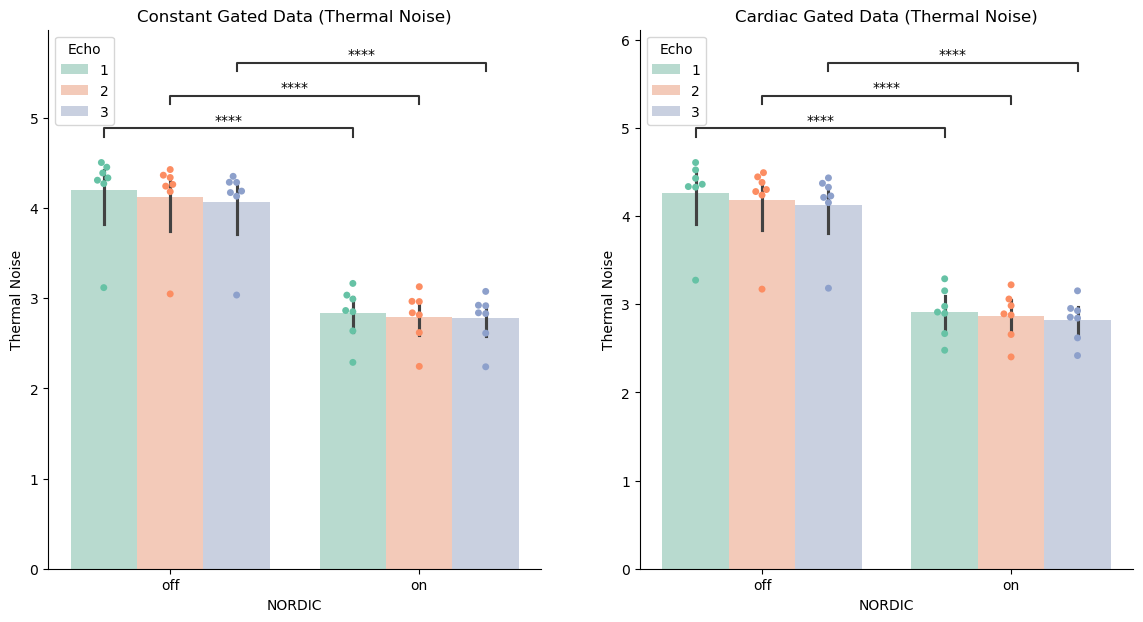

In [7]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ConstG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Constant Gated Data (Thermal Noise)')
sns.swarmplot(data=df_ConstG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False)
pairs=[(('off',1),('on',1)),(('off',2),('on',2)),(('off',3),('on',3))]
annotation = Annotator(axs[0], pairs, data=df_ConstG, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_CardG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Cardiac Gated Data (Thermal Noise)')
sns.swarmplot(data=df_CardG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False)
sns.despine()
pairs=[(('off',1),('on',1)),(('off',2),('on',2)),(('off',3),('on',3))]
annotation = Annotator(axs[1], pairs, data=df_CardG, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();

In [9]:
df = df.infer_objects()
(100*(df.set_index('NORDIC').loc['off','Thermal Noise'].reset_index(drop=True) - df.set_index('NORDIC').loc['on','Thermal Noise'].reset_index(drop=True)) / df.set_index('NORDIC').loc['off','Thermal Noise'].reset_index(drop=True)).mean()

np.float64(31.612382202350275)

This next section creates a small dashboard to explore how thermal noise changes over time

In [10]:
xr_th = xr.DataArray(dims=['Subject','Session','NORDIC','Echo','TR'],
                     coords={'Subject':sbj_list,'Session':ses_list,'NORDIC':['on','off'],'Echo':range(1,4),'TR':range(185)}, name='Thermal Noise')

In [11]:
for sbj,ses in tqdm(dataset_info_df.index, desc='Scan'):
    for e in range(1,4):
        for NORDIC in ['on','off']:
            aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_{NORDIC}.ThermalNoise.txt')
            xr_th.loc[sbj,ses,NORDIC,e,:]      = np.loadtxt(aux_path)[10::]

Scan: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 189.21it/s]


In [12]:
sbj_sel = pn.widgets.Select(name='Subject', options=sbj_list, width=150)
ses_sel = pn.widgets.Select(name='Session', options=ses_list, width=150)
nor_sel = pn.widgets.Select(name='NORDIC', options=['on','off'], width=150)

@pn.depends(sbj_sel,ses_sel,nor_sel)
def get_th_timeseries_plot(sbj,ses,NORDIC):
    line_plot = xr_th.sel(Subject=sbj,Session=ses,NORDIC=NORDIC).hvplot.line(by='Echo',width=1750, height=400)
    aux_means = xr_th.sel(Subject=sbj,Session=ses,NORDIC=NORDIC).mean(dim='TR').values
    e1_mean_line = hv.HLine(aux_means[0]).opts(color='lightblue', line_width=3, line_dash='dashed')
    e2_mean_line = hv.HLine(aux_means[1]).opts(color='red', line_width=3, line_dash='dashed')
    e3_mean_line = hv.HLine(aux_means[2]).opts(color='orange', line_width=3, line_dash='dashed')

    return e1_mean_line * e2_mean_line * e3_mean_line * line_plot 

In [1]:
import os
port_tunnel = int(os.environ['PORT2'])
print('++ INFO: Second Port available: %d' % port_tunnel)

KeyError: 'PORT2'

In [13]:
dashboard = pn.Row(pn.Card(sbj_sel,ses_sel,nor_sel, hide_header=True), get_th_timeseries_plot).show(port=port_tunnel)

Launching server at http://localhost:36525


In [14]:
dashboard.stop()